# Getting started with spatialdata-plot

This tutorial walks through the core mental model of [`spatialdata-plot`](https://github.com/scverse/spatialdata-plot): a fluent API on top of a `SpatialData` object that lets you layer the four spatial element types (images, labels, shapes, points) into a single matplotlib figure.

We use the lightweight built-in `blobs` dataset so this notebook runs in seconds with zero downloads. Once the API clicks, the same calls work on Visium, Xenium, MERFISH, or any other dataset that can be loaded as a `SpatialData` object — see the other tutorials in this gallery for real-world examples.

## The data

`sd.datasets.blobs()` returns a `SpatialData` object containing one image, one label mask, one points layer, and several shape layers — all aligned in the `global` coordinate system.

In [1]:
import spatialdata as sd
import spatialdata_plot  # noqa: F401  (registers the .pl accessor)

sdata = sd.datasets.blobs()
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## The fluent `.pl` API

Every plot follows the same shape:

```python
sdata.pl.render_<element>(...).pl.render_<element>(...).pl.show()
```

Each `render_*` call **stages** an element to draw and returns the `SpatialData` object, so calls chain. `pl.show()` draws everything onto a matplotlib figure.

### Render an image

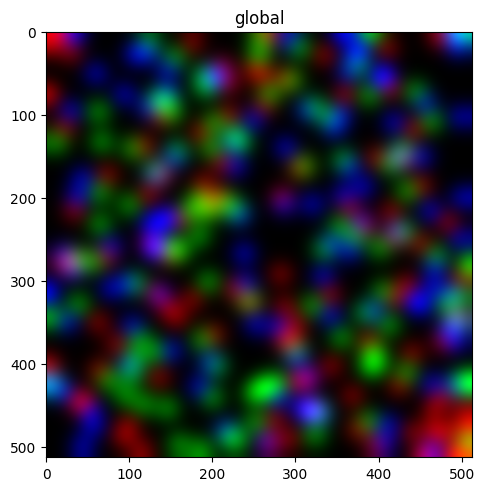

In [2]:
sdata.pl.render_images("blobs_image").pl.show()

### Render labels

By default, labels are filled. Use `contour_px` to draw boundaries instead — useful for overlaying segmentations on top of an image without hiding pixel-level detail.

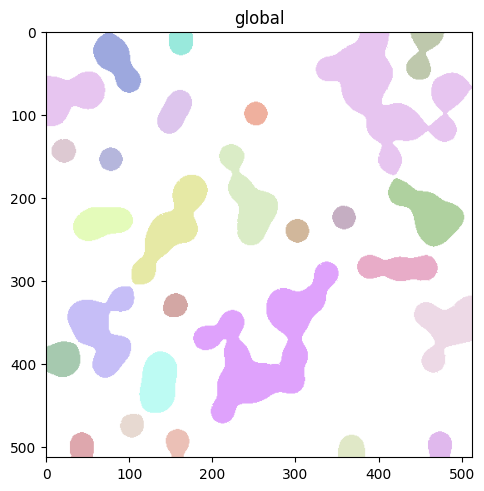

In [3]:
sdata.pl.render_labels("blobs_labels", contour_px=3).pl.show()

### Render points

Points carry per-row metadata (here, a `genes` column). Pass `color=` to color points by any column in the points dataframe or any var/obs column in the linked table.

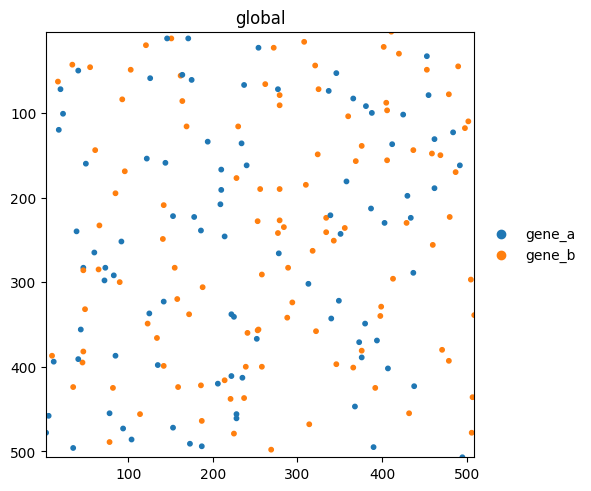

In [4]:
sdata.pl.render_points("blobs_points", color="genes", size=10).pl.show()

## Layering elements

The real value of the fluent API shows up when combining elements. Render order matters: later calls draw on top of earlier ones.

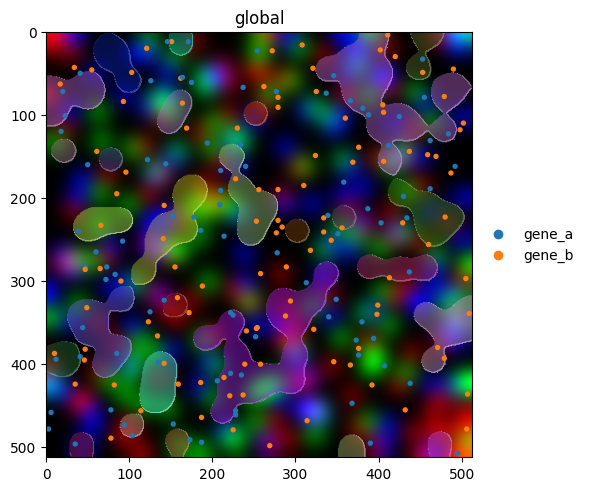

In [5]:
(
    sdata.pl.render_images("blobs_image")
    .pl.render_labels("blobs_labels", contour_px=2, outline_alpha=0.8)
    .pl.render_points("blobs_points", color="genes", size=8)
    .pl.show()
)

## Coloring by a feature

Both `render_labels` and `render_shapes` accept `color=` to map a column from the linked `AnnData` table onto element fill. Here we color label regions by a per-region intensity (`channel_0_sum`).

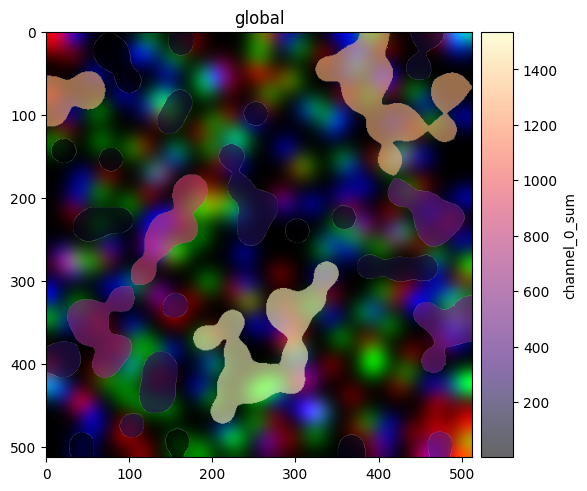

In [6]:
(
    sdata.pl.render_images("blobs_image")
    .pl.render_labels("blobs_labels", color="channel_0_sum", cmap="magma", fill_alpha=0.6)
    .pl.show()
)

## Styling a publication figure

Combine multiple parameters for a polished overlay. Most styling parameters mirror matplotlib's vocabulary (`cmap`, `alpha`, `linewidth`, named colors, hex codes), so anything you know from matplotlib works here too.

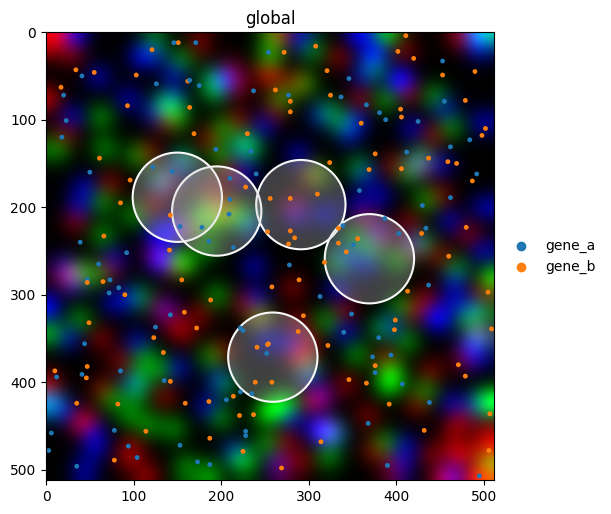

In [7]:
(
    sdata.pl.render_images("blobs_image")
    .pl.render_shapes(
        "blobs_circles",
        fill_alpha=0.3,
        outline_width=1.5,
        outline_color="white",
        outline_alpha=1.0,
    )
    .pl.render_points("blobs_points", color="genes", size=6)
    .pl.show(figsize=(6, 6))
)

## Where to next

- **API reference** — every parameter for every `render_*` is documented in the [plotting API](https://spatialdata.scverse.org/projects/plot/en/latest/api.html).
- **Real-data tutorials** — see the other notebooks in this gallery for Visium, Xenium, and MERFISH examples that combine these primitives into complete analyses.
- **Contributing** — found a missing example? Open a PR on [`spatialdata-plot-notebooks`](https://github.com/scverse/spatialdata-plot-notebooks).